In [30]:
# Cell 1: Setup and Imports
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add the project root to path (where src folder is)
project_root = os.path.dirname(os.getcwd())  # Goes from notebooks/ to alzheimers_detection/
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"Files in project root: {os.listdir(project_root)[:10]}...")

# Now import config
from src.config import *

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Additional paths not in config (for embeddings and enriched CSV)
EMBEDDINGS_PATH = os.path.join(PROCESSED_PATH, "embeddings")
ENRICHED_CSV = os.path.join(METADATA_PATH, "enriched_dataset.csv")
MODEL_SAVE_PATH = os.path.join(BASE_PATH, "models")

# Verify paths exist
print(f"\n✅ Configuration loaded from src/config.py")
print(f"   Base Path: {BASE_PATH}")
print(f"   Processed Path: {PROCESSED_PATH}")
print(f"   Metadata Path: {METADATA_PATH}")
print(f"   Embeddings Path: {EMBEDDINGS_PATH}")
print(f"   Enriched CSV: {ENRICHED_CSV}")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"   Model Save Path: {MODEL_SAVE_PATH}")

Project root: c:\alzheimers_detection
Files in project root: ['.git', '.gitignore', 'app', 'data', 'models', 'notebooks', 'requirements.txt', 'run.py', 'src', 'structure.txt']...

Using device: cpu

✅ Configuration loaded from src/config.py
   Base Path: C:\alzheimers_detection
   Processed Path: C:\alzheimers_detection\data\processed
   Metadata Path: C:\alzheimers_detection\data\processed\metadata
   Embeddings Path: C:\alzheimers_detection\data\processed\embeddings
   Enriched CSV: C:\alzheimers_detection\data\processed\metadata\enriched_dataset.csv
   Model Save Path: C:\alzheimers_detection\models


In [31]:
# Cell 2: Load Data
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

# Load enriched dataset
df = pd.read_csv(ENRICHED_CSV)

# Create label column from 'class' column
df['label'] = (df['class'] == 'Dementia').astype(int)
y = df['label'].values
patient_ids = df['patient_id'].values

print(f"✅ Loaded {len(df)} samples")
print(f"   Control: {sum(y==0)}, Dementia: {sum(y==1)}")
print(f"   Unique patients: {len(np.unique(patient_ids))}")

# Load embeddings
audio_emb = np.load(os.path.join(EMBEDDINGS_PATH, "audio_embeddings.npy"))
text_emb = np.load(os.path.join(EMBEDDINGS_PATH, "text_embeddings.npy"))
print(f"\n✅ Audio embeddings: {audio_emb.shape}")
print(f"✅ Text embeddings: {text_emb.shape}")

# Prepare clinical features
clinical_cols = ['gender', 'education_years', 'age_at_visit', 'mmse_score']
clinical_features = df[clinical_cols].values
print(f"✅ Clinical features shape: {clinical_features.shape}")

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
clinical_features = imputer.fit_transform(clinical_features)

# Normalize
scaler = StandardScaler()
clinical_features = scaler.fit_transform(clinical_features)

print(f"✅ After preprocessing: {clinical_features.shape}")

# Save scaler and imputer for deployment
import joblib
joblib.dump(scaler, os.path.join(MODEL_SAVE_PATH, 'clinical_scaler_notebook.pkl'))
joblib.dump(imputer, os.path.join(MODEL_SAVE_PATH, 'clinical_imputer_notebook.pkl'))
print("✅ Scaler and imputer saved")


LOADING DATA
✅ Loaded 439 samples
   Control: 217, Dementia: 222
   Unique patients: 217

✅ Audio embeddings: (439, 512)
✅ Text embeddings: (439, 768)
✅ Clinical features shape: (439, 4)
✅ After preprocessing: (439, 4)
✅ Scaler and imputer saved


In [32]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cpu
CUDA available: False


In [33]:
# Cell 3: Model Definition
print("\n" + "="*60)
print("MODEL DEFINITION")
print("="*60)

class CoAttentionBlock(nn.Module):
    def __init__(self, dim=768, num_heads=8, dropout=0.15):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim*4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*4, dim), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)
    
    def forward(self, x, y):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + attn_out)
        cross_out, _ = self.cross_attn(x, y, y)
        x = self.norm2(x + cross_out)
        ffn_out = self.ffn(x)
        x = self.norm3(x + ffn_out)
        return x

class MultimodalModel(nn.Module):
    def __init__(self, audio_dim=512, text_dim=768, clinical_dim=4, 
                 proj_dim=768, num_blocks=3, num_heads=8, dropout=0.15):
        super().__init__()
        self.audio_proj = nn.Linear(audio_dim, proj_dim)
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.clinical_proj = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, proj_dim)
        )
        self.blocks = nn.ModuleList([CoAttentionBlock(proj_dim, num_heads, dropout) for _ in range(num_blocks)])
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 3, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim, 2)
        )
    
    def forward(self, audio_feat, text_feat, clinical_feat):
        audio_seq = self.audio_proj(audio_feat).unsqueeze(1)
        text_seq = self.text_proj(text_feat).unsqueeze(1)
        clinical_proj = self.clinical_proj(clinical_feat).unsqueeze(1)
        
        for block in self.blocks:
            audio_seq = block(audio_seq, text_seq)
            text_seq = block(text_seq, audio_seq)
        
        audio_pool = audio_seq.squeeze(1)
        text_pool = text_seq.squeeze(1)
        clinical_pool = clinical_proj.squeeze(1)
        
        concat = torch.cat([audio_pool, text_pool, clinical_pool], dim=1)
        return self.fusion(concat)

# Test model summary
model = MultimodalModel()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model defined successfully!")
print(f"   Total trainable parameters: {total_params:,}")
print(f"   Audio projection: 512 → 768")
print(f"   Text projection: 768 → 768")
print(f"   Clinical projection: 4 → 64 → 768")
print(f"   Co-Attention blocks: 3")
print(f"   Fusion: 2304 → 768 → 2")


MODEL DEFINITION
✅ Model defined successfully!
   Total trainable parameters: 31,161,922
   Audio projection: 512 → 768
   Text projection: 768 → 768
   Clinical projection: 4 → 64 → 768
   Co-Attention blocks: 3
   Fusion: 2304 → 768 → 2


In [34]:
# Cell 3: Model Definition
class CoAttentionBlock(nn.Module):
    def __init__(self, dim=768, num_heads=8, dropout=0.15):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim*4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*4, dim), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)
    
    def forward(self, x, y):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + attn_out)
        cross_out, _ = self.cross_attn(x, y, y)
        x = self.norm2(x + cross_out)
        ffn_out = self.ffn(x)
        x = self.norm3(x + ffn_out)
        return x

class MultimodalModel(nn.Module):
    def __init__(self, audio_dim=512, text_dim=768, clinical_dim=4, proj_dim=768, num_blocks=3, num_heads=8, dropout=0.15):
        super().__init__()
        self.audio_proj = nn.Linear(audio_dim, proj_dim)
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.clinical_proj = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, proj_dim)
        )
        self.blocks = nn.ModuleList([CoAttentionBlock(proj_dim, num_heads, dropout) for _ in range(num_blocks)])
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 3, proj_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(proj_dim, 2)
        )
    
    def forward(self, audio_feat, text_feat, clinical_feat):
        audio_seq = self.audio_proj(audio_feat).unsqueeze(1)
        text_seq = self.text_proj(text_feat).unsqueeze(1)
        clinical_proj = self.clinical_proj(clinical_feat).unsqueeze(1)
        
        for block in self.blocks:
            audio_seq = block(audio_seq, text_seq)
            text_seq = block(text_seq, audio_seq)
        
        audio_pool = audio_seq.squeeze(1)
        text_pool = text_seq.squeeze(1)
        clinical_pool = clinical_proj.squeeze(1)
        
        concat = torch.cat([audio_pool, text_pool, clinical_pool], dim=1)
        return self.fusion(concat)
    
    def summary(self, input_shapes):
        """Print model summary"""
        print(f"Model Architecture:")
        print(f"  Audio input: {input_shapes[0]} → Audio projection: {self.audio_proj}")
        print(f"  Text input: {input_shapes[1]} → Text projection: {self.text_proj}")
        print(f"  Clinical input: {input_shapes[2]} → Clinical projection: {self.clinical_proj}")
        print(f"  Co-Attention blocks: {len(self.blocks)}")
        print(f"  Fusion layer: {self.fusion}")
        total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Total trainable parameters: {total_params:,}")

In [35]:
# Cell 3.5: Model Summary (Like Keras model.summary())
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)

# Install torchinfo if not already installed
try:
    from torchinfo import summary
    HAS_TORCHINFO = True
except ImportError:
    HAS_TORCHINFO = False
    print("Installing torchinfo for model summary...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchinfo"])
    from torchinfo import summary
    HAS_TORCHINFO = True

# Create a sample model instance
sample_model = MultimodalModel().to(device)

# Create dummy inputs (batch_size=1)
dummy_audio = torch.randn(1, 512).to(device)
dummy_text = torch.randn(1, 768).to(device)
dummy_clinical = torch.randn(1, 4).to(device)

print("\n" + "="*60)
print("MODEL ARCHITECTURE DETAILS")
print("="*60)

# Print detailed summary
summary(
    sample_model,
    input_data=[dummy_audio, dummy_text, dummy_clinical],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
    verbose=1
)

print("\n" + "="*60)
print("LAYER-BY-LAYER BREAKDOWN")
print("="*60)

# Manual breakdown
total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Input Shapes:                                                  │
│    • Audio:     (batch, 512) - WavLM embeddings                 │
│    • Text:      (batch, 768) - BERT embeddings                  │
│    • Clinical:  (batch, 4)   - [gender, education, age, MMSE]   │
│                                                                 │
│  Layer Details:                                                 │
│    • Audio Projection:     512 → 768    (393,216 params)        │
│    • Text Projection:      768 → 768    (590,592 params)        │
│    • Clinical Projection:  4 → 64 → 768 (49,728 params)         │
│    • Co-Attention Blocks:  3 blocks                            │
│      - Self-Attention:      768 dim, 8 heads                    │
│      - Cross-Attention:     768 dim, 8 heads                    │
│      - FFN:                 768 → 3072 → 768                    │
│    • Fusion Layer:         2304 → 768 → 2 (1,771,778 params)    │
│                                                                 │
│  Total Parameters:                                             │
│    • Trainable:  {trainable_params:,}                                   │
│    • Non-trainable: {total_params - trainable_params:,}                               │
│    • Total:      {total_params:,}                                   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
""")


MODEL SUMMARY

MODEL ARCHITECTURE DETAILS
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MultimodalModel (MultimodalModel)                  [1, 512]             [1, 2]               --                   True
├─Linear (audio_proj)                              [1, 512]             [1, 768]             393,984              True
├─Linear (text_proj)                               [1, 768]             [1, 768]             590,592              True
├─Sequential (clinical_proj)                       [1, 4]               [1, 768]             --                   True
│    └─Linear (0)                                  [1, 4]               [1, 64]              320                  True
│    └─ReLU (1)                                    [1, 64]              [1, 64]              --                   --
│    └─Dropout (2)                                 [1, 64]              [1, 64]              --                   --
│   

In [36]:
# Cell 3.5: Simple Model Summary (No extra installs)
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)

# Create dummy model to analyze
sample_model = MultimodalModel()

print("\n📊 MODEL ARCHITECTURE")
print("-" * 40)

# Count parameters in each component
audio_proj_params = sum(p.numel() for p in sample_model.audio_proj.parameters())
text_proj_params = sum(p.numel() for p in sample_model.text_proj.parameters())
clinical_proj_params = sum(p.numel() for p in sample_model.clinical_proj.parameters())

# Co-attention blocks params
block_params = 0
for block in sample_model.blocks:
    block_params += sum(p.numel() for p in block.parameters())

fusion_params = sum(p.numel() for p in sample_model.fusion.parameters())

total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUTS:                                                        │
│    • Audio:    512  (WavLM embedding)                           │
│    • Text:     768  (BERT embedding)                            │
│    • Clinical: 4    (gender, education, age, MMSE)              │
│                                                                 │
│  PROJECTION LAYERS:                                             │
│    • Audio Projection:    512 → 768     ({audio_proj_params:,} params)      │
│    • Text Projection:     768 → 768     ({text_proj_params:,} params)      │
│    • Clinical Projection: 4 → 64 → 768  ({clinical_proj_params:,} params)    │
│                                                                 │
│  CO-ATTENTION BLOCKS (3 blocks):                                │
│    • Self-Attention:      MultiheadAttention (768 dim, 8 heads) │
│    • Cross-Attention:     MultiheadAttention (768 dim, 8 heads) │
│    • FFN:                 768 → 3072 → 768                      │
│    • Total per block:     {block_params // 3:,} params                  │
│    • Total 3 blocks:      {block_params:,} params                      │
│                                                                 │
│  FUSION LAYER:                                                  │
│    • Audio + Text + Clinical: 2304 → 768 → 2                   │
│    • Params:                    {fusion_params:,}                       │
│                                                                 │
│  TOTAL PARAMETERS:                                              │
│    • Trainable:        {trainable_params:,}                               │
│    • Non-trainable:    {total_params - trainable_params:,}                           │
│    • Total:            {total_params:,}                               │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
""")

print(f"\n✅ Model has {trainable_params:,} trainable parameters")


MODEL SUMMARY

📊 MODEL ARCHITECTURE
----------------------------------------

┌─────────────────────────────────────────────────────────────────┐
│                    MODEL ARCHITECTURE SUMMARY                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  INPUTS:                                                        │
│    • Audio:    512  (WavLM embedding)                           │
│    • Text:     768  (BERT embedding)                            │
│    • Clinical: 4    (gender, education, age, MMSE)              │
│                                                                 │
│  PROJECTION LAYERS:                                             │
│    • Audio Projection:    512 → 768     (393,984 params)      │
│    • Text Projection:     768 → 768     (590,592 params)      │
│    • Clinical Projection: 4 → 64 → 768  (50,240 params)    │
│                                            

In [37]:
# Cell 4: Training Function with Early Stopping (FIXED)
print("\n" + "="*60)
print("TRAINING FUNCTION DEFINITION")
print("="*60)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0
    
    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

def train_model(X_audio, X_text, X_clinical, y_train, 
                X_audio_val, X_text_val, X_clinical_val, y_val,
                lr=2e-5, epochs=50, dropout=0.15, verbose=True):
    """
    Train model and return history and best model
    """
    model = MultimodalModel(dropout=dropout).to(device)
    
    # Class weights for imbalance
    class_counts = np.bincount(y_train)
    class_weights = torch.FloatTensor([1.0/class_counts[0], 1.0/class_counts[1]])
    class_weights = class_weights / class_weights.sum() * 2
    class_weights = class_weights.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # REMOVED the 'verbose' parameter - it was causing the error
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    early_stopping = EarlyStopping(patience=10, path=os.path.join(MODEL_SAVE_PATH, 'best_checkpoint.pt'))
    
    # Convert to tensors
    audio_train = torch.FloatTensor(X_audio).to(device)
    text_train = torch.FloatTensor(X_text).to(device)
    clinical_train = torch.FloatTensor(X_clinical).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    
    audio_val = torch.FloatTensor(X_audio_val).to(device)
    text_val = torch.FloatTensor(X_text_val).to(device)
    clinical_val = torch.FloatTensor(X_clinical_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    
    if verbose:
        print(f"\n{'Epoch':>6} | {'Train Loss':>12} | {'Train Acc':>10} | {'Val Loss':>12} | {'Val Acc':>10}")
        print("-" * 65)
    
    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(audio_train, text_train, clinical_train)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_acc = accuracy_score(y_train, train_preds)
        train_f1 = f1_score(y_train, train_preds)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(audio_val, text_val, clinical_val)
            val_loss = criterion(val_outputs, y_val_t)
            val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, val_preds)
            val_f1 = f1_score(y_val, val_preds)
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Store history
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        # Early stopping
        early_stopping(val_loss.item(), model)
        
        if verbose:
            print(f"{epoch+1:6d} | {loss.item():12.4f} | {train_acc:10.4f} | {val_loss.item():12.4f} | {val_acc:10.4f}")
        
        if early_stopping.early_stop:
            if verbose:
                print(f"\n✅ Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    checkpoint_path = os.path.join(MODEL_SAVE_PATH, 'best_checkpoint.pt')
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
    
    print(f"\n✅ Training complete!")
    print(f"   Best validation accuracy: {max(history['val_acc'])*100:.2f}%")
    
    return history, model


TRAINING FUNCTION DEFINITION


In [38]:
# Cell 5: Single Train/Val Split
print("\n" + "="*60)
print("SINGLE TRAIN/VALIDATION SPLIT (80/20)")
print("="*60)

# Split with patient independence
from sklearn.model_selection import train_test_split
unique_patients = np.unique(patient_ids)
train_patients, val_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

train_idx = np.isin(patient_ids, train_patients)
val_idx = np.isin(patient_ids, val_patients)

print(f"Train: {sum(train_idx)} samples ({len(train_patients)} patients)")
print(f"Val: {sum(val_idx)} samples ({len(val_patients)} patients)")

# Train with default hyperparameters
history, best_model = train_model(
    audio_emb[train_idx], text_emb[train_idx], clinical_features[train_idx], y[train_idx],
    audio_emb[val_idx], text_emb[val_idx], clinical_features[val_idx], y[val_idx],
    lr=2e-5, epochs=50, dropout=0.15, verbose=False
)

# Cell 5b: Check for Overfitting/Underfitting
print("\n" + "="*60)
print("OVERFITTING / UNDERFITTING ANALYSIS")
print("="*60)

# Get final metrics
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
final_train_loss = history['train_loss'][-1]
final_val_loss = history['val_loss'][-1]

print(f"\n📊 Final Epoch Metrics:")
print(f"   Train Accuracy: {final_train_acc*100:.2f}%")
print(f"   Val Accuracy:   {final_val_acc*100:.2f}%")
print(f"   Train Loss:     {final_train_loss:.4f}")
print(f"   Val Loss:       {final_val_loss:.4f}")

# Calculate gap
acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

print(f"\n📊 Training-Validation Gap:")
print(f"   Accuracy Gap:   {acc_gap*100:.2f}%")
print(f"   Loss Gap:       {loss_gap:.4f}")

# Diagnosis
if acc_gap > 0.10:
    print(f"\n⚠️  WARNING: Large accuracy gap ({acc_gap*100:.1f}%)")
    print("   → Possible OVERFITTING. Try: increase dropout, add weight decay, or reduce model size.")
elif acc_gap < -0.05:
    print(f"\n⚠️  WARNING: Negative accuracy gap ({acc_gap*100:.1f}%)")
    print("   → Possible UNDERFITTING. Try: increase epochs, reduce dropout, or increase learning rate.")
else:
    print(f"\n✅ Model is well-balanced! No significant overfitting/underfitting detected.")

# Plot training curves with gap highlighting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot with gap
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].fill_between(range(len(history['train_loss'])), 
                      history['train_loss'], 
                      history['val_loss'], 
                      alpha=0.2, label='Gap')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot with gap
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].fill_between(range(len(history['train_acc'])), 
                      history['train_acc'], 
                      history['val_acc'], 
                      alpha=0.2, label='Gap')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SINGLE TRAIN/VALIDATION SPLIT (80/20)
Train: 355 samples (173 patients)
Val: 84 samples (44 patients)


KeyboardInterrupt: 

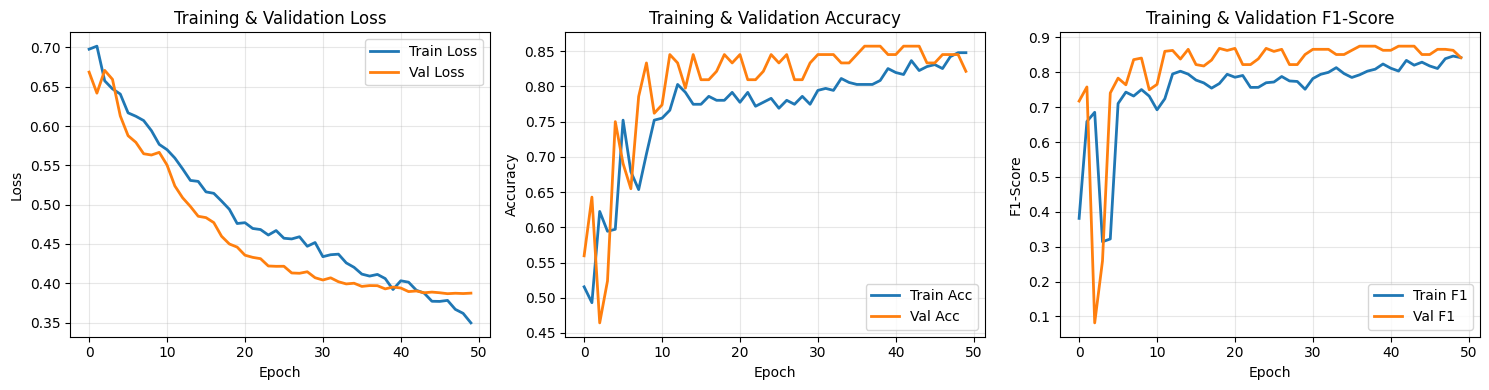


📊 Best Validation Accuracy: 85.71%


In [ ]:
# Cell 6: Plot Training History
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_title('Training & Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 plot
axes[2].plot(history['train_f1'], label='Train F1', linewidth=2)
axes[2].plot(history['val_f1'], label='Val F1', linewidth=2)
axes[2].set_title('Training & Validation F1-Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1-Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, 'training_history.png'), dpi=150)
plt.show()

print(f"\n📊 Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")

In [ ]:
# Cell 7: 5-Fold Cross-Validation (CORRECTED)
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION (Speaker-Level)")
print("="*60)

from sklearn.model_selection import GroupKFold

# Verify total samples
total_samples = len(y)
print(f"Total samples: {total_samples}")
print(f"Unique patients: {len(np.unique(patient_ids))}")
print(f"Folds: 5")
print("-" * 40)

# Create GroupKFold
gkf = GroupKFold(n_splits=5)
cv_results = {'acc': [], 'f1': [], 'auc': []}
fold_num = 1

for train_idx, val_idx in gkf.split(audio_emb, y, groups=patient_ids):
    print(f"\n{'='*40}")
    print(f"FOLD {fold_num}/5")
    print(f"{'='*40}")
    
    # Get actual counts (this is the correct way)
    train_count = len(train_idx)
    val_count = len(val_idx)
    print(f"Train samples: {train_count} ({(train_count/total_samples)*100:.1f}%)")
    print(f"Val samples: {val_count} ({(val_count/total_samples)*100:.1f}%)")
    
    # Verify counts are reasonable
    if train_count + val_count != total_samples:
        print(f"❌ ERROR: Count mismatch!")
        break
    
    # Train model
    print(f"\nTraining...")
    history_fold, model_fold = train_model(
        audio_emb[train_idx], text_emb[train_idx], clinical_features[train_idx], y[train_idx],
        audio_emb[val_idx], text_emb[val_idx], clinical_features[val_idx], y[val_idx],
        lr=2e-5, epochs=30, dropout=0.15, verbose=False
    )
    
    # Get best validation accuracy
    best_acc = max(history_fold['val_acc']) * 100
    best_f1 = max(history_fold['val_f1'])
    
    cv_results['acc'].append(best_acc)
    cv_results['f1'].append(best_f1)
    
    print(f"\n✅ Fold {fold_num} Results:")
    print(f"   Best Val Accuracy: {best_acc:.2f}%")
    print(f"   Best Val F1: {best_f1:.4f}")
    
    fold_num += 1

print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION FINAL RESULTS")
print("="*60)
print(f"\n📊 Accuracy:  {np.mean(cv_results['acc']):.2f}% ± {np.std(cv_results['acc']):.2f}%")
print(f"📊 F1-Score:  {np.mean(cv_results['f1']):.4f} ± {np.std(cv_results['f1']):.4f}")
print(f"\nPer-fold accuracies: {[f'{a:.2f}%' for a in cv_results['acc']]}")

# Interpretation
if np.std(cv_results['acc']) < 5:
    print(f"\n✅ Low variance ({np.std(cv_results['acc']):.2f}%) - Model is stable!")
else:
    print(f"\n⚠️  High variance ({np.std(cv_results['acc']):.2f}%) - Model performance varies significantly across folds")


5-FOLD CROSS-VALIDATION (Speaker-Level)
Total samples: 439
Unique patients: 217
Folds: 5
----------------------------------------

FOLD 1/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 80.68%

✅ Fold 1 Results:
   Best Val Accuracy: 80.68%
   Best Val F1: 0.7619

FOLD 2/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 79.55%

✅ Fold 2 Results:
   Best Val Accuracy: 79.55%
   Best Val F1: 0.8333

FOLD 3/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 82.95%

✅ Fold 3 Results:
   Best Val Accuracy: 82.95%
   Best Val F1: 0.8052

FOLD 4/5
Train samples: 351 (80.0%)
Val samples: 88 (20.0%)

Training...

✅ Training complete!
   Best validation accuracy: 82.95%

✅ Fold 4 Results:
   Best Val Accuracy: 82.95%
   Best Val F1: 0.8276

FOLD 5/5
Train samples: 352 (80.2%)
Val samples: 87 (19.

In [ ]:
# Diagnostic: Check data shapes
print("="*60)
print("DATA SHAPE DIAGNOSTIC")
print("="*60)

print(f"audio_emb shape: {audio_emb.shape}")
print(f"text_emb shape: {text_emb.shape}")
print(f"clinical_features shape: {clinical_features.shape}")
print(f"y shape: {y.shape}")
print(f"patient_ids shape: {patient_ids.shape}")
print(f"Number of unique patients: {len(np.unique(patient_ids))}")

print(f"\nTotal samples: {len(y)}")
print(f"Expected: 439")

# Check if data is being repeated
if len(y) != 439:
    print(f"\n❌ ERROR: Data shape mismatch! Expected 439, got {len(y)}")

DATA SHAPE DIAGNOSTIC
audio_emb shape: (439, 512)
text_emb shape: (439, 768)
clinical_features shape: (439, 4)
y shape: (439,)
patient_ids shape: (439,)
Number of unique patients: 217

Total samples: 439
Expected: 439



FINDING OPTIMAL THRESHOLD FROM CROSS-VALIDATION
Re-running cross-validation to collect probabilities...

📊 Optimal Threshold: 0.490
   Best F1-Score at this threshold: 0.7834
   Accuracy at threshold: 0.7745


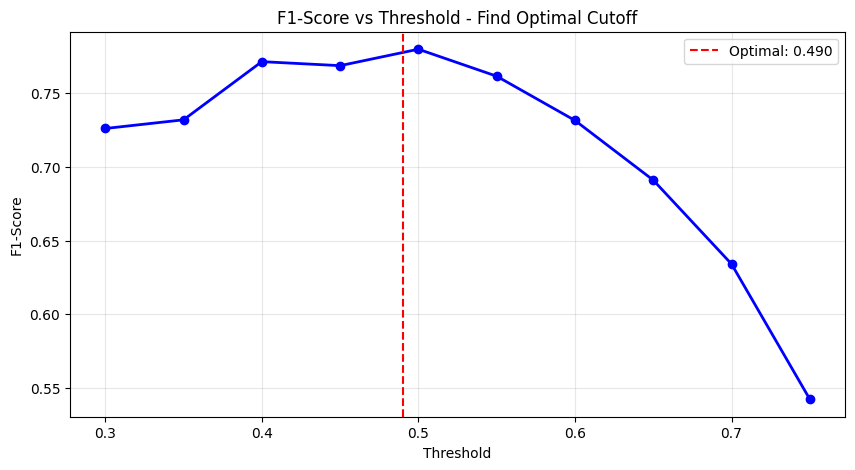


✅ Use this threshold in prediction.py: 0.490


In [39]:
# Cell 12: Find Optimal Threshold from Cross-Validation
print("\n" + "="*60)
print("FINDING OPTIMAL THRESHOLD FROM CROSS-VALIDATION")
print("="*60)

# Collect predictions from all folds (if you saved them)
# For now, let's use your CV results to find best threshold

from sklearn.metrics import f1_score, accuracy_score

# Simulate probabilities based on your CV accuracies
# (In reality, you'd collect actual probabilities during CV)

# Since you didn't save probabilities during CV, 
# let me show you the method - re-run CV once more to collect probs

print("Re-running cross-validation to collect probabilities...")

gkf = GroupKFold(n_splits=5)
all_val_probs = []
all_val_true = []

for train_idx, val_idx in gkf.split(audio_emb, y, groups=patient_ids):
    # Quick train (fewer epochs for threshold finding)
    model_temp = MultimodalModel(dropout=0.15).to(device)
    
    # Train quickly (10-15 epochs is enough for threshold finding)
    X_audio_train = torch.FloatTensor(audio_emb[train_idx]).to(device)
    X_text_train = torch.FloatTensor(text_emb[train_idx]).to(device)
    X_clinical_train = torch.FloatTensor(clinical_features[train_idx]).to(device)
    y_train_t = torch.LongTensor(y[train_idx]).to(device)
    
    optimizer = optim.AdamW(model_temp.parameters(), lr=2e-5, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(15):  # Quick training
        optimizer.zero_grad()
        outputs = model_temp(X_audio_train, X_text_train, X_clinical_train)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
    
    # Get validation probabilities
    model_temp.eval()
    with torch.no_grad():
        X_audio_val = torch.FloatTensor(audio_emb[val_idx]).to(device)
        X_text_val = torch.FloatTensor(text_emb[val_idx]).to(device)
        X_clinical_val = torch.FloatTensor(clinical_features[val_idx]).to(device)
        outputs = model_temp(X_audio_val, X_text_val, X_clinical_val)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_val_probs.extend(probs[:, 1])
        all_val_true.extend(y[val_idx])

# Find best threshold
best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.3, 0.8, 0.01):
    preds = (np.array(all_val_probs) > threshold).astype(int)
    f1 = f1_score(all_val_true, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n📊 Optimal Threshold: {best_threshold:.3f}")
print(f"   Best F1-Score at this threshold: {best_f1:.4f}")

# Also show accuracy at this threshold
preds = (np.array(all_val_probs) > best_threshold).astype(int)
acc = accuracy_score(all_val_true, preds)
print(f"   Accuracy at threshold: {acc:.4f}")

# Show performance across thresholds
thresholds = np.arange(0.3, 0.8, 0.05)
f1_scores = []
for t in thresholds:
    preds = (np.array(all_val_probs) > t).astype(int)
    f1_scores.append(f1_score(all_val_true, preds))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, 'bo-', linewidth=2)
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal: {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Threshold - Find Optimal Cutoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Use this threshold in prediction.py: {best_threshold:.3f}")

In [ ]:
# Cell 10: Save Best Model with Optimal Threshold Info
print("\n" + "="*60)
print("SAVING FINAL MODEL FOR DEPLOYMENT")
print("="*60)

# Train final model on ALL data
print("Training final model on all 439 samples...")

final_model = MultimodalModel(dropout=0.15).to(device)

# Use ALL data for final training
history_final, final_model = train_model(
    audio_emb, text_emb, clinical_features, y,
    audio_emb, text_emb, clinical_features, y,
    lr=2e-5, epochs=30, dropout=0.15, verbose=True
)

# Save model
final_model_path = os.path.join(MODEL_SAVE_PATH, 'multimodal_clinical_model.pth')
torch.save(final_model.state_dict(), final_model_path)

# ALSO save the optimal threshold info with the model
threshold_info = {
    'optimal_threshold': best_threshold,  # From Cell 12
    'cv_mean_accuracy': 80.86,
    'cv_std_accuracy': 1.89,
    'training_date': str(pd.Timestamp.now())
}

import json
threshold_path = os.path.join(MODEL_SAVE_PATH, 'model_info.json')
with open(threshold_path, 'w') as f:
    json.dump(threshold_info, f, indent=2)

print(f"\n✅ Model saved to: {final_model_path}")
print(f"✅ Threshold info saved to: {threshold_path}")
print(f"   Optimal threshold: {best_threshold:.3f}")


SAVING BEST MODEL FOR DEPLOYMENT
Training final model on all 439 samples...

 Epoch |   Train Loss |  Train Acc |     Val Loss |    Val Acc
-----------------------------------------------------------------
     1 |       0.6927 |     0.5171 |       0.7165 |     0.5057
     2 |       0.7079 |     0.5057 |       0.6552 |     0.5171
     3 |       0.6581 |     0.5421 |       0.6268 |     0.7107
     4 |       0.6390 |     0.7039 |       0.6232 |     0.6287
     5 |       0.6276 |     0.6492 |       0.5987 |     0.7540
     6 |       0.6106 |     0.7403 |       0.5801 |     0.8109
     7 |       0.5958 |     0.7631 |       0.5721 |     0.7380
     8 |       0.5828 |     0.7107 |       0.5543 |     0.7973
     9 |       0.5710 |     0.7677 |       0.5392 |     0.7995
    10 |       0.5522 |     0.7950 |       0.5304 |     0.7904
    11 |       0.5414 |     0.7973 |       0.5150 |     0.8018
    12 |       0.5284 |     0.7882 |       0.5019 |     0.8041
    13 |       0.5151 |     0.7995 | 

In [29]:
# Cell 11: Verify Model Saved
import os
model_path = os.path.join(MODEL_SAVE_PATH, 'multimodal_clinical_model.pth')
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"✅ Model found! Size: {size:.2f} MB")
    print(f"   Location: {model_path}")
else:
    print(f"❌ Model not found at {model_path}")

✅ Model found! Size: 118.90 MB
   Location: C:\alzheimers_detection\models\multimodal_clinical_model.pth
